In [101]:
%matplotlib qt
#%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
# Use Arial everywhere (falls back if not available)
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,          # base font size
    "axes.titlesize": 16,     # figure/axes titles
    "axes.labelsize": 13,     # x/y labels
    "legend.fontsize": 11,    # legend text
    "xtick.labelsize": 11,    # tick labels
    "ytick.labelsize": 11,
    "figure.titlesize": 18,   # suptitle
})

In [1]:
import ast
import re
import numpy as np
import pandas as pd
from pathlib import Path

def _parse_w_from_csv_cell(cell):
    """
    cell looks like a string:
      "[[ 0.01]\n [-0.02]\n ...]"
    Returns np.ndarray shape (n_ch, 1) float.
    """
    if cell is None or (isinstance(cell, float) and np.isnan(cell)):
        return None

    # If it’s already an array-like
    if isinstance(cell, (list, tuple, np.ndarray)):
        w = np.array(cell, dtype=float)
        return w.reshape(-1, 1)

    s = str(cell).strip()

    # 1) try literal_eval on a python-style nested list
    try:
        w = np.array(ast.literal_eval(s), dtype=float)
        return w.reshape(-1, 1)
    except Exception:
        pass

    # 2) fallback: regex all numbers
    nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", s)
    if not nums:
        return None
    w = np.array([float(x) for x in nums], dtype=float).reshape(-1, 1)
    return w

class RidgeResultLookup:
    """
    Cache the ridge CSV in memory and provide (w, lag_ms) per subject.
    Also exposes .subjects (sorted unique).
    """
    def __init__(self, csv_path):
        self.csv_path = Path(csv_path)
        df = pd.read_csv(self.csv_path)

        # robust subject parsing
        df["subject"] = df["subject"].astype(int)

        # if there are accidental duplicates, keep the last occurrence
        df = df.drop_duplicates(subset=["subject"], keep="last")

        self.df = df.set_index("subject", drop=False)

        # ✅ list of subjects coming from the file
        self.subjects = sorted(self.df.index.astype(int).tolist())

    def load_subject(self, sub, which="star"):
        sub = int(sub)
        if sub not in self.df.index:
            return None, 0

        row = self.df.loc[sub]

        if which == "star":
            w = _parse_w_from_csv_cell(row.get("w_star"))
            lag_ms = int(row.get("best_lag_ms_star", 0))
        elif which == "lam0":
            w = _parse_w_from_csv_cell(row.get("w_lam0"))
            lag_ms = int(row.get("best_lag_ms_lam0", 0))
        else:
            raise ValueError("which must be 'star' or 'lam0'")

        return w, lag_ms


In [2]:
import numpy as np

# import these from your ridge file
from ridge_regression_functions import (
    load_all_trials,
    split_trials_by_condition,
    normalise_eeg,
    WIN_OFFSET1,
    WIN_OFFSET2,
)

SAMPLE_RATE = 100.0  # 10 ms/sample → 100 Hz (this matches your pipeline) :contentReference[oaicite:5]{index=5}

def _project_and_align_ridge(eeg, pupil, w, lag_samples=0):
    """
    Match ridge_regression_functions.concat_trials() alignment convention:
      +lag => EEG delayed (drop early EEG, drop late pupil)
      -lag => EEG advanced (drop late EEG, drop early pupil)
    And do: window -> lag trim -> normalise_eeg -> projection.
    """
    if w is None:
        return np.empty(0), np.empty(0)

    # shapes
    eeg = np.asarray(eeg)
    if eeg.ndim == 1:
        eeg = eeg[:, None]  # (T, C)

    pupil = np.asarray(pupil)
    pupil_1d = pupil[:, 0] if (pupil.ndim == 2 and pupil.shape[1] == 1) else pupil.ravel()

    # common window (same idea as concat_trials)
    T0 = min(len(eeg), len(pupil_1d))
    if T0 <= 0:
        return np.empty(0), np.empty(0)

    start = WIN_OFFSET1
    stop  = T0 - WIN_OFFSET2
    if stop <= start:
        return np.empty(0), np.empty(0)

    eeg_w   = eeg[start:stop, :]
    pupil_w = pupil_1d[start:stop]
    Tw = len(pupil_w)
    if Tw <= 0:
        return np.empty(0), np.empty(0)

    # lag trim (NO roll, NO wrap)
    if abs(lag_samples) >= Tw:
        return np.empty(0), np.empty(0)

    if lag_samples >= 0:
        eeg_seg   = eeg_w[lag_samples:, :]
        pupil_seg = pupil_w[:Tw - lag_samples]
    else:
        s = -lag_samples
        eeg_seg   = eeg_w[:Tw - s, :]
        pupil_seg = pupil_w[s:]

    if len(pupil_seg) == 0:
        return np.empty(0), np.empty(0)

    # IMPORTANT: normalise EEG like ridge did before fitting w
    eeg_seg = normalise_eeg(eeg_seg)

    # weights shape checks
    w = np.asarray(w).reshape(-1, 1)  # (C,1)
    C = eeg_seg.shape[1]
    if w.shape[0] != C:
        # safest is to skip — otherwise you’re multiplying mismatched channels
        # (you can add channel-name matching here if needed)
        return np.empty(0), np.empty(0)

    eeg_roi = (eeg_seg @ w).ravel()  # (T,)

    return eeg_roi, pupil_seg


def _trialwise_z(x):
    x = np.asarray(x)
    if x.size == 0:
        return x
    mu = x.mean()
    sd = x.std(ddof=0)
    return (x - mu) / (sd if sd > 0 else 1.0)


In [3]:
def extract_trials_for_plot_ridge(
    ridge_csv_path,
    eeg_root,
    pupil_root,
    subjects=None,
    loads=(5, 9, 13),
    tasks=("memory", "control"),
    which="star",
    z_per_trial=True,
    use_lag_for_plot=True,   # ✅ new
):
    eeg_root = Path(eeg_root)
    pupil_root = Path(pupil_root)

    ridge_lookup = RidgeResultLookup(ridge_csv_path)

    if subjects is None:
        subjects = ridge_lookup.subjects
    if not subjects:
        print("No subjects found in ridge CSV.")
        return None

    panel_trials = {(cond, load): {"eeg": [], "pupil": []}
                    for cond in tasks for load in loads}

    for sub in subjects:
        print(f"Loading subject {sub}...")

        w, lag_ms = ridge_lookup.load_subject(sub, which=which)
        if w is None:
            print(f"  sub {sub}: no ridge weights ({which}); skipping.")
            continue

        # ✅ for stimulus-locked visualisation, force lag=0
        if not use_lag_for_plot:
            lag_samples = 0
        else:
            lag_samples = int(round(lag_ms / 10.0))

        try:
            trials = load_all_trials(int(sub), eeg_root, pupil_root)
        except Exception as e:
            print(f"  sub {sub}: load_all_trials failed ({e}); skipping.")
            continue

        mem, ctl = split_trials_by_condition(trials)
        by_cond = {"memory": mem, "control": ctl}

        for cond in tasks:
            for eeg, pupil, meta in by_cond[cond]:
                L = meta.get("load", None)
                if L not in loads:
                    continue

                eeg_roi, pupil_1d = _project_and_align_ridge(eeg, pupil, w, lag_samples)
                if eeg_roi.size == 0:
                    continue

                if z_per_trial:
                    eeg_roi  = _trialwise_z(eeg_roi)
                    pupil_1d = _trialwise_z(pupil_1d)

                panel_trials[(cond, L)]["eeg"].append(eeg_roi)
                panel_trials[(cond, L)]["pupil"].append(pupil_1d)

    return panel_trials


def plot_grand_average_trials(panel_trials, tasks = ["memory", "control"], loads=(5,9,13), z_per_trial=True, save_name="grand_average_trials2.png"):
# --- plot 3×2 grid ---
    colors = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}
    fig, axes = plt.subplots(len(loads), 2, figsize=(12, 9), sharey="row")
    legend_handles, legend_labels = [], []

    for r, load in enumerate(loads):
        for c, cond in enumerate(tasks):
            ax = axes[r, c]
            eeg_list  = panel_trials[(cond, load)]["eeg"]
            pup_list  = panel_trials[(cond, load)]["pupil"]

            if not eeg_list:
                ax.set_visible(False)
                continue

            # align all trials to the shortest length for this panel
            Lmin = min(map(len, eeg_list + pup_list))
            eeg_stack = np.stack([e[:Lmin] for e in eeg_list], axis=0)  # (Ntrials, L)
            pup_stack = np.stack([p[:Lmin] for p in pup_list], axis=0)

            # grand mean ± SEM across trials
            eeg_mu  = eeg_stack.mean(0)
            eeg_sem = eeg_stack.std(0, ddof=1) / np.sqrt(eeg_stack.shape[0])

            pup_mu  = pup_stack.mean(0)
            pup_sem = pup_stack.std(0, ddof=1) / np.sqrt(pup_stack.shape[0])

            # time axis (assumes 100 Hz)
            t = np.arange(Lmin) / 100.0

            ln1, = ax.plot(t, pup_mu, color=colors[load], label="Pupil")
            ax.fill_between(t, pup_mu - pup_sem, pup_mu + pup_sem, color=colors[load], alpha=.25)

            axr = ax.twinx()
            ln2, = axr.plot(t, eeg_mu, color="black", lw=1.2, label="θ")
            axr.fill_between(t, eeg_mu - eeg_sem, eeg_mu + eeg_sem, color="black", alpha=.15)

            # ✅ use the actual time range of your data
            ax.set_xlim(t[0], 25)
            ax.set_yticks([]); axr.set_yticks([])
            ax.axvline(0, ls="--", c="k", lw=.7)

            if c == 0:
                ax.set_ylabel(f"Load {load:02d}")
            if r == 0:
                n_tr = eeg_stack.shape[0]
                ax.set_title(f"{cond.capitalize()}")

            if not legend_handles:
                legend_handles.extend([ln1, ln2])
                legend_labels.extend(["Pupil", "θ"])

    axes[0, 0].legend(legend_handles, legend_labels, loc="upper right", frameon=False)
    total_trials = sum(len(panel_trials[k]["eeg"]) for k in panel_trials)
    #fig.suptitle(f"Grand average across trials (total N={total_trials}, z_per_trial={z_per_trial})")
    fig.tight_layout(rect=[0, 0.03, 1, 0.97])
    return fig


In [18]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pickle

def save_panel_trials(panel_trials, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "wb") as f:
        pickle.dump(panel_trials, f, protocol=pickle.HIGHEST_PROTOCOL)

def load_panel_trials(path):
    with open(path, "rb") as f:
        return pickle.load(f)


# --- Define your 3 components here (EDIT PATHS if needed) ---
COMPONENTS = {
    "Combined": {
        "ridge_csv": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_ALL\dfk_ridge_ALL.csv",
        "eeg_root":  r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_theta_processed2",   # <- change if yours is different
        "pupil_root":r"C:/Users/cdd/Documents/Uni/Special_course/pupil_processed_clara",                    # <- change if yours is different
    },
    "Tonic": {
        "ridge_csv": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW\dfk_ridge.csv",
        "eeg_root":  r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_slow",
        "pupil_root":r"C:\Users\cdd\Documents\Uni\Special_course\pupil_slow",
    },
    "Phasic": {
        "ridge_csv": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST\dfk_ridge.csv",
        "eeg_root":  r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\eeg_fast",  # <- change if needed
        "pupil_root":r"C:\Users\cdd\Documents\Uni\Special_course\pupil_fast",                    # <- change if needed
    },
}

OUT_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\plots")
OUT_DIR.mkdir(parents=True, exist_ok=True)

all_panel_trials = {}  # ✅ keep in memory too

for comp_name, cfg in COMPONENTS.items():
    print(f"\n=== {comp_name} ===")
    use_lag_for_plot = True  # default to using best lag for plotting
    if comp_name == "Combined":
        use_lag_for_plot = False  # ✅ use actual best lag for Combined (since it’s already a mix)
    panel_trials = extract_trials_for_plot_ridge(
        ridge_csv_path=cfg["ridge_csv"],
        eeg_root=cfg["eeg_root"],
        pupil_root=cfg["pupil_root"],
        subjects=None,           # from CSV
        which="star",            # or "lam0"
        loads=(5, 9, 13),
        tasks=("memory", "control"),
        z_per_trial=True,
        use_lag_for_plot=use_lag_for_plot,  # ✅ stimulus-locked
    )

    if panel_trials is None:
        continue

    # ✅ store in memory
    all_panel_trials[comp_name] = panel_trials

    # ✅ save to disk
    pkl_path = OUT_DIR / f"panel_trials_{comp_name.lower()}.pkl"
    save_panel_trials(panel_trials, pkl_path)
    print(f"Saved panel_trials: {pkl_path}")

    fig = plot_grand_average_trials(
        panel_trials,
        tasks=["memory", "control"],
        loads=(5, 9, 13),
        z_per_trial=True,
    )
    fig.suptitle(f"{comp_name} (ridge: w*, best lag per subject)", y=1.02)

    out_path = OUT_DIR / f"grand_average_{comp_name.lower()}.png"
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_path}")



=== Combined ===
Loading subject 33...


KeyboardInterrupt: 

In [4]:
from pathlib import Path
import pickle

PLOTS_DIR = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\plots")

def load_panel_trials(pkl_path):
    with open(pkl_path, "rb") as f:
        return pickle.load(f)

all_panel_trials = {
    "Combined": load_panel_trials(PLOTS_DIR / "panel_trials_combined_lock.pkl"),
    "Tonic":    load_panel_trials(PLOTS_DIR / "panel_trials_tonic.pkl"),
    "Phasic":   load_panel_trials(PLOTS_DIR / "panel_trials_phasic.pkl"),
}

print({k: len(v) for k, v in all_panel_trials.items()})  # sanity check


{'Combined': 6, 'Tonic': 6, 'Phasic': 6}


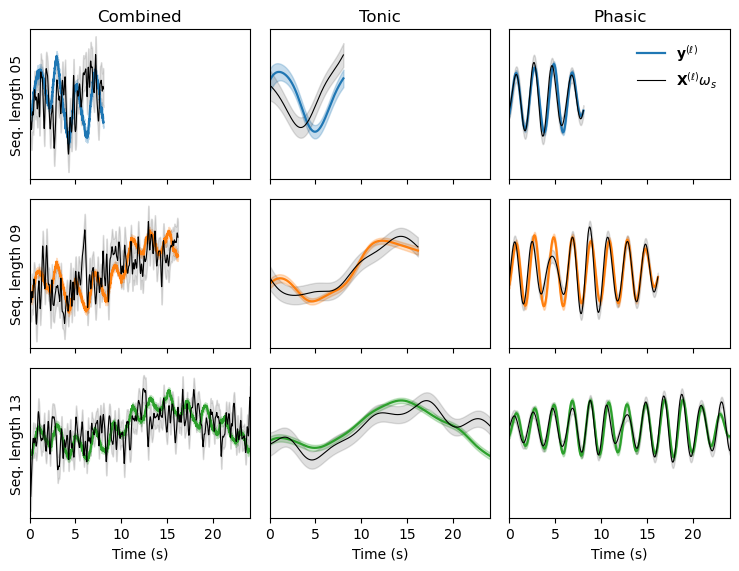

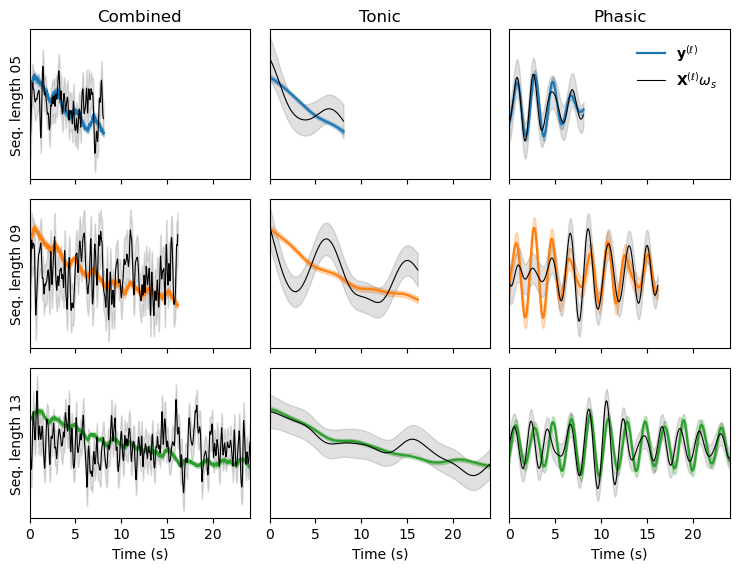

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def _sem(stack):
    n = stack.shape[0]
    if n <= 1:
        return np.zeros(stack.shape[1], dtype=float)
    return stack.std(axis=0, ddof=1) / np.sqrt(n)

def _zscore_mean_and_sem(mu, sem, eps=1e-12):
    """
    Z-score the mean time series over time; scale SEM accordingly.
    """
    mu = np.asarray(mu, float)
    sem = np.asarray(sem, float)
    m = mu.mean()
    s = mu.std(ddof=0)
    if s < eps:
        return mu * 0.0, sem * 0.0
    return (mu - m) / s, sem / s

def plot_component_grid_zavg(
    all_panel_trials,
    cond,
    loads=(5, 9, 13),
    components_order=("Combined", "Tonic", "Phasic"),
    fs=100.0,
    max_time=25.0,
):
    # map component names robustly
    keymap = {k.lower(): k for k in all_panel_trials.keys()}
    comps = [keymap.get(c.lower(), c) for c in components_order]
    comps = [c for c in comps if c in all_panel_trials]

    colors = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}

    fig, axes = plt.subplots(
        len(loads), len(comps),
        figsize=(2.5 * len(comps), 2 * len(loads)),
        sharex="row",
        sharey="row",   # ✅ same y within each load row
    )
    axes = np.atleast_2d(axes)

    # column titles
    for j, comp in enumerate(comps):
        axes[0, j].set_title(comp, fontsize=12)

    legend_done = False

    for i, load in enumerate(loads):
        # common length for this row (across components)
        row_Lmins = []
        for comp in comps:
            eeg_list = all_panel_trials[comp].get((cond, load), {}).get("eeg", [])
            pup_list = all_panel_trials[comp].get((cond, load), {}).get("pupil", [])
            if eeg_list and pup_list:
                row_Lmins.append(min(map(len, eeg_list + pup_list)))
        if not row_Lmins:
            for j in range(len(comps)):
                axes[i, j].set_visible(False)
            continue

        Lrow = min(row_Lmins)
        t = np.arange(Lrow) / fs
        tmax = min(max_time, t[-1]) if t.size else max_time

        for j, comp in enumerate(comps):
            ax = axes[i, j]
            cell = all_panel_trials[comp].get((cond, load), {"eeg": [], "pupil": []})
            eeg_list = cell["eeg"]
            pup_list = cell["pupil"]

            if not eeg_list or not pup_list:
                ax.set_visible(False)
                continue

            eeg_stack = np.stack([e[:Lrow] for e in eeg_list], axis=0)
            pup_stack = np.stack([p[:Lrow] for p in pup_list], axis=0)

            eeg_mu  = eeg_stack.mean(axis=0)
            eeg_sem = _sem(eeg_stack)
            pup_mu  = pup_stack.mean(axis=0)
            pup_sem = _sem(pup_stack)

            # ✅ z-score the averages (and scale SEM) BEFORE plotting
            pup_mu_z, pup_sem_z = _zscore_mean_and_sem(pup_mu, pup_sem)
            eeg_mu_z, eeg_sem_z = _zscore_mean_and_sem(eeg_mu, eeg_sem)

            ln1, = ax.plot(t, pup_mu_z, color=colors[load], lw=1.6, label="Pupil")
            ax.fill_between(t, pup_mu_z - pup_sem_z, pup_mu_z + pup_sem_z, color=colors[load], alpha=0.25)

            ln2, = ax.plot(t, eeg_mu_z, color="black", lw=0.8, label="θ")
            ax.fill_between(t, eeg_mu_z - eeg_sem_z, eeg_mu_z + eeg_sem_z, color="black", alpha=0.12)

            ax.axvline(0, ls="--", c="k", lw=0.7)
            ax.set_xlim(0, 24)

            if j == 0:
                ax.set_ylabel(f"Seq. length {load:02d}")
            else:
                ax.set_yticks([])

            if i == len(loads) - 1:
                ax.set_xlabel("Time (s)")
                ax.tick_params(axis="x", labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)

            if not legend_done and i == 0 and j == len(comps) - 1:
                ax.legend([ln1, ln2], [r"$\mathbf{y}^{(\ell)}$", r"$\mathbf{X}^{(\ell)}\omega_s$"], loc="upper right", frameon=False)
                legend_done = True

    #fig.suptitle(f"{cond.capitalize()} — z-scored grand-average traces", y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig

fig_mem = plot_component_grid_zavg(all_panel_trials, cond="memory")
fig_ctl = plot_component_grid_zavg(all_panel_trials, cond="control")
plt.show()



In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_best_lag_histograms_1x3(
    csv_paths,                    # dict: {"Combined": path, "Tonic": path, "Phasic": path}
    which="star",                 # "star" or "lam0"
    bins="auto",
    show_ms=True,
    sharey=True
):
    col = "best_lag_ms_star" if which == "star" else "best_lag_ms_lam0"
    xlabel = "Best lag (ms)" if show_ms else "Best lag (s)"

    # ---- load all lags first (so we can share x-lims) ----
    data = {}
    for name, path in csv_paths.items():
        df = pd.read_csv(path)
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found in {path}")
        lags_ms = pd.to_numeric(df[col], errors="coerce").dropna().to_numpy()
        x = lags_ms if show_ms else (lags_ms / 1000.0)
        x = -x #to be consistent with other studies
        data[name] = x

    # shared x-limits
    all_x = np.concatenate(list(data.values()))
    xmin, xmax = np.min(all_x), np.max(all_x)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=sharey)
    axes = np.atleast_1d(axes)


    for ax, (name, x) in zip(axes, data.items()):
        ax.hist(x, bins=bins)
        ax.axvline(0, linestyle="-", linewidth=1, color="gray")
        ax.set_title(name)
        ax.set_xlabel(xlabel)
        ax.set_xlim(xmin, xmax)
        m = np.mean(x)
        med = np.median(x)

        ax.axvline(m,  linestyle="--",  linewidth=1.5, label="Mean", color="orange")
        ax.axvline(med, linestyle=":", linewidth=1.8, label="Median", color="red")


        if name == "Phasic":   # or use an index check
            ax.legend(frameon=False, loc="upper left")


    axes[0].set_ylabel("Count")
    #fig.suptitle(f"Best lag distribution ({which})", y=1.02)
    fig.tight_layout()
    plt.show()
    return fig


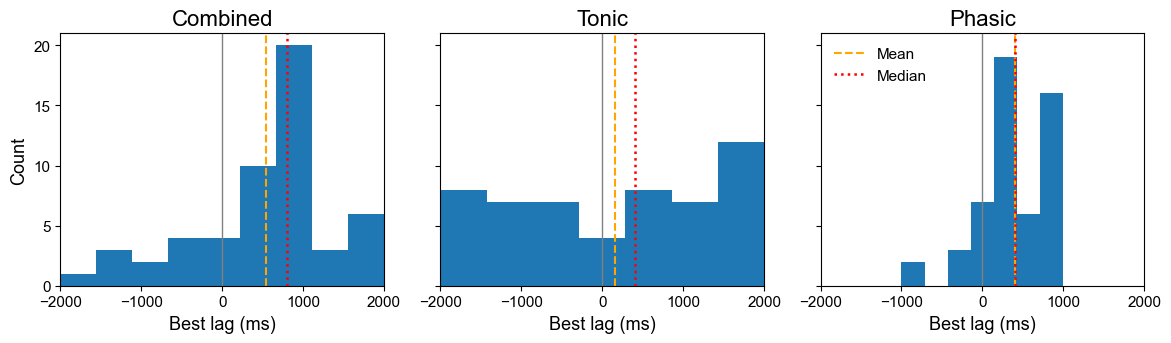

In [66]:
CSV_PATHS = {
    "Combined": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_ALL\dfk_ridge_ALL.csv",
    "Tonic":    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW\dfk_ridge.csv",
    "Phasic":   r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST\dfk_ridge.csv",
}

plot_best_lag_histograms_1x3(CSV_PATHS, which="star", bins="auto", show_ms=True)


TEST TRIALS

In [68]:
INDEX_ALL  = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit_ALL\cv_pred_index.csv")
INDEX_SLOW = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW\cv_pred_index.csv")  # tonic
INDEX_FAST = Path(r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit_FAST\cv_pred_index.csv")  # phasic

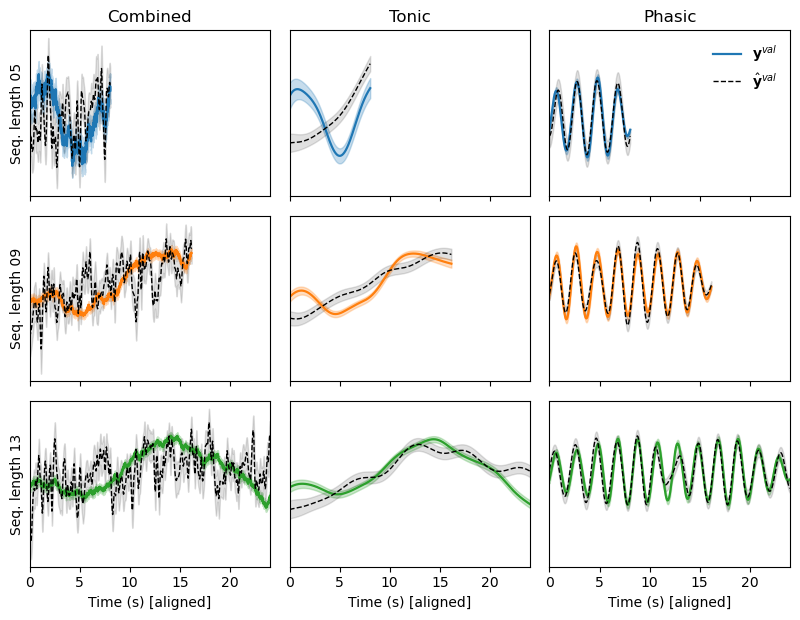

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------- utils ----------------
def _sem(stack: np.ndarray) -> np.ndarray:
    n = stack.shape[0]
    if n <= 1:
        return np.zeros(stack.shape[1], dtype=float)
    return stack.std(axis=0, ddof=1) / np.sqrt(n)

def _zscore_mean_and_sem(mu, sem, eps=1e-12):
    """Z-score the mean time series over time; scale SEM accordingly."""
    mu = np.asarray(mu, float)
    sem = np.asarray(sem, float)
    m = mu.mean()
    s = mu.std(ddof=0)
    if s < eps:
        return mu * 0.0, sem * 0.0
    return (mu - m) / s, sem / s

def _resolve_npz_path(npz_path: str, base_dir: Path) -> Path:
    p = Path(npz_path)
    if p.is_file():
        return p
    # try relative to index csv folder
    p2 = (base_dir / p).resolve()
    if p2.is_file():
        return p2
    # try normalize slashes
    p3 = (base_dir / Path(str(npz_path).replace("\\", "/"))).resolve()
    if p3.is_file():
        return p3
    raise FileNotFoundError(f"Could not find npz: {npz_path} (base={base_dir})")

def load_component_predictions(index_csv: str, *, subject=None):
    """
    Returns dict: load -> {"y": [1D arrays], "yhat": [1D arrays]}
    """
    base_dir = index_csv.parent
    df = pd.read_csv(index_csv)

    if subject is not None:
        df = df[df["subject"].astype(int) == int(subject)].copy()

    out = {}  # load -> dict lists
    for _, row in df.iterrows():
        load = int(row["load"])
        out.setdefault(load, {"y": [], "yhat": []})

        fn = _resolve_npz_path(row["npz_path"], base_dir)
        z = np.load(fn, allow_pickle=True)
        y = np.asarray(z["y"]).ravel()
        yhat = np.asarray(z["yhat"]).ravel()

        # safety: drop NaNs if any (optional)
        if not (np.isfinite(y).all() and np.isfinite(yhat).all()):
            continue

        out[load]["y"].append(y)
        out[load]["yhat"].append(yhat)

    return out

# ---------------- plotting ----------------
def plot_pred_grid_zavg(
    all_comp_preds: dict,
    loads=(5, 9, 13),
    components_order=("Combined", "Tonic", "Phasic"),
    fs=100.0,
    max_time=25.0,
    xlim=(0, 24),
    zscore_means=True,
):
    """
    all_comp_preds[component_name][load] -> {"y": [...], "yhat":[...]}
    """
    # robust component name matching
    keymap = {k.lower(): k for k in all_comp_preds.keys()}
    comps = [keymap.get(c.lower(), c) for c in components_order]
    comps = [c for c in comps if c in all_comp_preds]

    colors = {5: "#1f77b4", 9: "#ff7f0e", 13: "#2ca02c"}

    fig, axes = plt.subplots(
        len(loads), len(comps),
        figsize=(2.7 * len(comps), 2.1 * len(loads)),
        sharex="row",
        sharey="row",
    )
    axes = np.atleast_2d(axes)

    # column titles
    for j, comp in enumerate(comps):
        axes[0, j].set_title(comp, fontsize=12)

    legend_done = False

    for i, load in enumerate(loads):
        # common length for this row (across components)
        row_Lmins = []
        for comp in comps:
            cell = all_comp_preds[comp].get(load, {"y": [], "yhat": []})
            y_list = cell["y"]; yhat_list = cell["yhat"]
            if y_list and yhat_list:
                row_Lmins.append(min(map(len, y_list + yhat_list)))

        if not row_Lmins:
            for j in range(len(comps)):
                axes[i, j].set_visible(False)
            continue

        Lrow = min(row_Lmins)
        t = np.arange(Lrow) / fs
        tmax = min(max_time, t[-1]) if t.size else max_time

        for j, comp in enumerate(comps):
            ax = axes[i, j]
            cell = all_comp_preds[comp].get(load, {"y": [], "yhat": []})
            y_list = cell["y"]; yhat_list = cell["yhat"]

            if not y_list or not yhat_list:
                ax.set_visible(False)
                continue

            y_stack    = np.stack([y[:Lrow] for y in y_list], axis=0)
            yhat_stack = np.stack([yh[:Lrow] for yh in yhat_list], axis=0)

            y_mu,    y_sem    = y_stack.mean(axis=0), _sem(y_stack)
            yhat_mu, yhat_sem = yhat_stack.mean(axis=0), _sem(yhat_stack)

            if zscore_means:
                # z-score EACH mean trace over time (your earlier convention)
                y_mu_z, y_sem_z = _zscore_mean_and_sem(y_mu, y_sem)
                yhat_mu_z, yhat_sem_z = _zscore_mean_and_sem(yhat_mu, yhat_sem)
            else:
                y_mu_z, y_sem_z = y_mu, y_sem
                yhat_mu_z, yhat_sem_z = yhat_mu, yhat_sem

            ln1, = ax.plot(t, y_mu_z, color=colors[load], lw=1.6, label="y (true)")
            ax.fill_between(t, y_mu_z - y_sem_z, y_mu_z + y_sem_z, color=colors[load], alpha=0.25)

            ln2, = ax.plot(t, yhat_mu_z, color="black", lw=1.0, ls="--", label="ŷ (CV)")
            ax.fill_between(t, yhat_mu_z - yhat_sem_z, yhat_mu_z + yhat_sem_z, color="black", alpha=0.12)

            ax.axvline(0, ls="--", c="k", lw=0.7)
            ax.set_xlim(*xlim)

            if j == 0:
                ax.set_ylabel(f"Seq. length {load:02d}")
            else:
                ax.set_yticks([])

            if i == len(loads) - 1:
                ax.set_xlabel("Time (s) [aligned]")
                ax.tick_params(axis="x", labelbottom=True)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis="x", labelbottom=False)

            if not legend_done and i == 0 and j == len(comps) - 1:
                ax.legend([ln1, ln2], [r"$\mathbf{y}^{val}$", r"$\hat{\mathbf{y}}^{val}$"], loc="upper right", frameon=False)

                legend_done = True

    fig.tight_layout()
    return fig

# set subject=None for grand-average across all subjects, or subject=33 etc.
subject = None

all_comp_preds = {
    "Combined": load_component_predictions(INDEX_ALL,  subject=subject),
    "Tonic":    load_component_predictions(INDEX_SLOW, subject=subject),
    "Phasic":   load_component_predictions(INDEX_FAST, subject=subject),
}



fig = plot_pred_grid_zavg(all_comp_preds, loads=(5, 9, 13), fs=100.0, zscore_means=True)
plt.show()


In [102]:
fig = plot_pred_grid_zavg(all_comp_preds, loads=(5, 9, 13), fs=100.0, zscore_means=True)
plt.show()

In [71]:
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.stats.anova import AnovaRM

LOADS = [5, 9, 13]

# ---------- helpers ----------
def fisher_z(r, eps=1e-7):
    r = np.asarray(r, float)
    r = np.clip(r, -1 + eps, 1 - eps)
    return np.arctanh(r)

def partial_eta_sq(F, df_effect, df_error):
    return float((F * df_effect) / (F * df_effect + df_error))

def load_index(path: Path, component_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["component"] = component_name
    df["subject"] = df["subject"].astype(int)
    df["load"] = df["load"].astype(int)
    return df[df["load"].isin(LOADS)].copy()

def make_cell_means(df_long: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """
    Collapse trial-level rows -> subject × component × load cell means.
    Returns columns: subject, component, load, value_col
    """
    cell = (df_long
            .groupby(["subject", "component", "load"], as_index=False)[value_col]
            .mean()
           )

    # keep only complete subjects (all 3 components × 3 loads = 9 cells)
    n_cells = cell.groupby("subject").size()
    keep = n_cells[n_cells == (3 * 3)].index
    cell = cell[cell["subject"].isin(keep)].copy()

    # make factors categorical (helps printing + ensures stable ordering)
    cell["component"] = pd.Categorical(cell["component"], categories=["Combined", "Tonic", "Phasic"], ordered=True)
    cell["load"] = pd.Categorical(cell["load"], categories=LOADS, ordered=True)

    return cell

def run_rm_anova(cell: pd.DataFrame, depvar: str, *, fisher=False, title=""):
    dat = cell.copy()
    if fisher:
        dat[depvar] = fisher_z(dat[depvar].values)
        dv_name = depvar + "_z"
        dat = dat.rename(columns={depvar: dv_name})
    else:
        dv_name = depvar

    print("\n" + "="*80)
    print(title)
    print("N subjects (complete):", dat["subject"].nunique())
    print("Cell counts (should be 9 per subject):")
    print(dat.groupby("subject").size().describe())

    aov = AnovaRM(
        data=dat,
        depvar=dv_name,
        subject="subject",
        within=["component", "load"]
    ).fit()

    print("\nANOVA table:")
    print(aov)

    # Add partial eta^2 for each effect
    tbl = aov.anova_table.copy()
    # statsmodels uses row labels like 'component', 'load', 'component:load'
    for eff in tbl.index:
        F = float(tbl.loc[eff, "F Value"])
        df1 = float(tbl.loc[eff, "Num DF"])
        df2 = float(tbl.loc[eff, "Den DF"])
        tbl.loc[eff, "eta_p2"] = partial_eta_sq(F, df1, df2)

    print("\nANOVA table with partial eta^2:")
    print(tbl)

    return aov, tbl

# ---------- load + stack the three components ----------
df_all  = load_index(INDEX_ALL,  "Combined")
df_slow = load_index(INDEX_SLOW, "Tonic")
df_fast = load_index(INDEX_FAST, "Phasic")

df = pd.concat([df_all, df_slow, df_fast], ignore_index=True)

# ---------- build subject×component×load means ----------
cell_r   = make_cell_means(df, "r_trial")
cell_mse = make_cell_means(df, "mse_trial")

# ---------- run 2-factor RM-ANOVA ----------
aov_r,   tbl_r   = run_rm_anova(cell_r,   "r_trial",   fisher=True,
                                title="2×RM-ANOVA on r_trial (Fisher-z), factors: component × load")
aov_mse, tbl_mse = run_rm_anova(cell_mse, "mse_trial", fisher=False,
                                title="2×RM-ANOVA on mse_trial, factors: component × load")



2×RM-ANOVA on r_trial (Fisher-z), factors: component × load
N subjects (complete): 53
Cell counts (should be 9 per subject):
count    53.0
mean      9.0
std       0.0
min       9.0
25%       9.0
50%       9.0
75%       9.0
max       9.0
dtype: float64

ANOVA table:
                    Anova
               F Value Num DF  Den DF  Pr > F
---------------------------------------------
component       9.0307 2.0000 104.0000 0.0002
load            1.2953 2.0000 104.0000 0.2782
component:load  2.0021 4.0000 208.0000 0.0955


ANOVA table with partial eta^2:
                 F Value  Num DF  Den DF    Pr > F    eta_p2
component       9.030682     2.0   104.0  0.000242  0.147970
load            1.295268     2.0   104.0  0.278204  0.024304
component:load  2.002055     4.0   208.0  0.095483  0.037074

2×RM-ANOVA on mse_trial, factors: component × load
N subjects (complete): 53
Cell counts (should be 9 per subject):
count    53.0
mean      9.0
std       0.0
min       9.0
25%       9.0
50%       9.

In [90]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, ttest_rel
import statsmodels.api as sm
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

# ---------------- helpers ----------------
def fisher_z(r, eps=1e-7):
    r = np.asarray(r, float)
    r = np.clip(r, -1 + eps, 1 - eps)
    return np.arctanh(r)

def cohen_dz_paired(x, y):
    d = x - y
    return float(np.nanmean(d) / (np.nanstd(d, ddof=1) + 1e-12))

def partial_eta_sq(F, df_effect, df_error):
    return float((F * df_effect) / (F * df_effect + df_error))

def resolve_npz(npz_path, base_dir: Path):
    p = Path(npz_path)
    if p.is_file():
        return p
    p2 = (base_dir / p).resolve()
    if p2.is_file():
        return p2
    p3 = (base_dir / Path(str(npz_path).replace("\\", "/"))).resolve()
    if p3.is_file():
        return p3
    raise FileNotFoundError(npz_path)

import numpy as np
from scipy.stats import pearsonr

import numpy as np
from scipy.stats import pearsonr

def recombined_metrics_for_subject_load(df_sub_load, base_dir, *, ddof_std=0):
    ys, yhats = [], []
    for _, row in df_sub_load.iterrows():
        fn = resolve_npz(row["npz_path"], base_dir)
        z = np.load(fn, allow_pickle=True)
        y = np.asarray(z["y"]).ravel()
        yhat = np.asarray(z["yhat"]).ravel()
        if len(y) == 0 or len(yhat) == 0:
            continue
        if not (np.isfinite(y).all() and np.isfinite(yhat).all()):
            continue
        ys.append(y); yhats.append(yhat)

    if not ys:
        return np.nan, np.nan

    y_all = np.concatenate(ys)
    yhat_all = np.concatenate(yhats)

    mse = float(np.mean((yhat_all - y_all) ** 2))
    if np.std(y_all, ddof=ddof_std) == 0 or np.std(yhat_all, ddof=ddof_std) == 0:
        r = np.nan
    else:
        r = float(pearsonr(yhat_all, y_all)[0])

    return r, mse


# ---------------- load index ----------------
df = pd.read_csv(INDEX_SLOW)
base_dir = INDEX_SLOW.parent

# keep only memory loads (digit-span memory trials)
df["subject"] = df["subject"].astype(int)
df["load"] = df["load"].astype(int)
df = df[df["load"].isin([5, 9, 13])].copy()

# ---------------- choose metric per subject×load ----------------
USE_RECOMBINED = False  # <-- set False to use mean trial-level r_trial
metric = "z" ## "z" or "mse"
rows = []
for subj, df_sub in df.groupby("subject"):
    for load, df_sl in df_sub.groupby("load"):
        if USE_RECOMBINED:
            r, mse = recombined_metrics_for_subject_load(df_sl, base_dir)
        else:
            r = float(np.nanmean(df_sl["r_trial"].values))
            mse = float(np.nanmean(df_sl["mse_trial"].values))
        rows.append({"subject": subj, "load": load, "r": r, "mse": mse})

wide = pd.DataFrame(rows).dropna()

# require complete cases for AnovaRM (all 3 loads per subject)
counts = wide.groupby("subject")["load"].nunique()
keep_subjects = counts[counts == 3].index
wide = wide[wide["subject"].isin(keep_subjects)].copy()

# Fisher-z transform for RM-ANOVA
wide["z"] = fisher_z(wide["r"].values)

print("N subjects (complete):", wide["subject"].nunique())
print(wide.groupby("load")[metric].describe())

# ---------------- RM ANOVA (within-subject factor = load) ----------------
aov = AnovaRM(data=wide, depvar=metric, subject="subject", within=["load"]).fit()
print(aov)

# Extract F and dfs for effect size (partial eta^2)
# statsmodels prints it; pull from table:
tbl = aov.anova_table
F = float(tbl.loc["load", "F Value"])
df_effect = float(tbl.loc["load", "Num DF"])
df_error = float(tbl.loc["load", "Den DF"])
eta_p2 = partial_eta_sq(F, df_effect, df_error)
print(f"partial eta^2 (load) = {eta_p2:.4f}")

# ---------------- planned contrast: specific load > mean(other two) ----------------
# Example: test load 13 > mean(load 5, load 9). (Change target_load to 5 or 9 if desired.)
target_load = 9

pivot = wide.pivot(index="subject", columns="load", values=metric)
z5, z9, z13 = pivot[5], pivot[9], pivot[13]

if target_load == 13:
    diff = z13 - 0.5 * (z5 + z9)
elif target_load == 9:
    diff = z9 - 0.5 * (z5 + z13)
elif target_load == 5:
    diff = z5 - 0.5 * (z9 + z13)
else:
    raise ValueError("target_load must be 5, 9, or 13")

t, p_two = ttest_rel(diff, np.zeros_like(diff), nan_policy="omit", alternative="greater")  # equivalent to one-sample on diff
dz = float(np.nanmean(diff) / (np.nanstd(diff, ddof=1) + 1e-12))

print(f"\nPlanned contrast: load {target_load} > mean(other two)")
print(f"t={t:.3f}, p(one-sided)={p_two:.4g}, dz={dz:.3f}")

target_load = 5

pivot = wide.pivot(index="subject", columns="load", values="z")
z5, z9, z13 = pivot[5], pivot[9], pivot[13]

if target_load == 13:
    diff = z13 - 0.5 * (z5 + z9)
elif target_load == 9:
    diff = z9 - 0.5 * (z5 + z13)
elif target_load == 5:
    diff = z5 - 0.5 * (z9 + z13)
else:
    raise ValueError("target_load must be 5, 9, or 13")

t, p_two = ttest_rel(diff, np.zeros_like(diff), nan_policy="omit", alternative="less")  # equivalent to one-sample on diff
dz = float(np.nanmean(diff) / (np.nanstd(diff, ddof=1) + 1e-12))

print(f"\nPlanned contrast: load {target_load} < mean(other two)")
print(f"t={t:.3f}, p(one-sided)={p_two:.4g}, dz={dz:.3f}")

tests = []
# 1) 9 different than 13 (two-sided)
#t_913, p_913 = ttest_rel(z9, z13, alternative="two-sided", nan_policy="omit")
#tests.append(("9 vs 13 (two-sided)", t_913, p_913, float(np.mean(z9 - z13))))

# 2) 5 lower than 9 (one-sided: 5 < 9)
t_59, p_59 = ttest_rel(z5, z9, alternative="less", nan_policy="omit")
tests.append(("5 < 9 (one-sided)", t_59, p_59, float(np.mean(z5 - z9))))

# 3) 5 lower than 13 (one-sided: 5 < 13)
t_513, p_513 = ttest_rel(z5, z13, alternative="less", nan_policy="omit")
tests.append(("5 < 13 (one-sided)", t_513, p_513, float(np.mean(z5 - z13))))

# Holm correction across these 3 tests
pvals = [p for _, _, p, _ in tests]
rej, p_holm, _, _ = multipletests(pvals, method="holm", alpha=0.05)

print("\nPaired tests (Holm-corrected across 3):")
for (name, t, p, md), ph, rj in zip(tests, p_holm, rej):
    print(f"{name:20s} t={t:+.3f}  p={p:.4g}  p_Holm={ph:.4g}  sig={rj}  mean_diff={md:+.4g}")


N subjects (complete): 53
      count      mean       std       min       25%       50%       75%  \
load                                                                      
5      53.0  0.072180  0.142058 -0.391300 -0.006802  0.088070  0.144067   
9      53.0  0.120335  0.125606 -0.226718  0.056302  0.124334  0.172061   
13     53.0  0.089267  0.146417 -0.464112  0.039145  0.102595  0.178585   

           max  
load            
5     0.327663  
9     0.470206  
13    0.353052  
               Anova
     F Value Num DF  Den DF  Pr > F
-----------------------------------
load  2.7702 2.0000 104.0000 0.0673

partial eta^2 (load) = 0.0506

Planned contrast: load 9 > mean(other two)
t=2.020, p(one-sided)=0.02429, dz=0.277

Planned contrast: load 5 < mean(other two)
t=-1.715, p(one-sided)=0.04616, dz=-0.236

Paired tests (Holm-corrected across 3):
5 < 9 (one-sided)    t=-2.026  p=0.02397  p_Holm=0.04794  sig=True  mean_diff=-0.04816
5 < 13 (one-sided)   t=-0.916  p=0.1819  p_Holm=0.1819 

In [46]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---------- helpers ----------
def _as_float(x):
    """Robust scalar extraction from npz entries."""
    try:
        arr = np.asarray(x)
        return float(arr.reshape(-1)[0])
    except Exception:
        try:
            return float(x.item())
        except Exception:
            return np.nan


def collect_trial_npz_scores(root_dir):
    """
    Read all *.npz under root_dir and return a DataFrame with:
    subject, fold, lag_ms, lam, r_trial, mse_trial, path
    """
    root = Path(root_dir)
    rows = []

    for p in root.rglob("*.npz"):
        try:
            z = np.load(p, allow_pickle=True)
        except Exception:
            continue

        # subject = first folder under root (expects root/sub-XX/...)
        try:
            subj = p.relative_to(root).parts[0]
        except Exception:
            subj = p.parent.name

        # fold
        if "fold" in z.files:
            fold = int(_as_float(z["fold"]))
        else:
            m = re.search(r"__fold(\d+)__", p.name)
            fold = int(m.group(1)) if m else np.nan

        # lag_ms
        if "lag_ms" in z.files:
            lag_ms = _as_float(z["lag_ms"])
        else:
            m = re.search(r"__lag([+-]?\d+)ms__", p.name)
            lag_ms = float(m.group(1)) if m else np.nan

        # lam
        if "lam" in z.files:
            lam = _as_float(z["lam"])
        else:
            m = re.search(r"__lam([0-9]*\.?[0-9]+)\.npz$", p.name)
            lam = float(m.group(1)) if m else np.nan

        # y, yhat -> per-trial metrics
        if "y" not in z.files or "yhat" not in z.files:
            continue
        y = np.asarray(z["y"]).astype(float).ravel()
        yhat = np.asarray(z["yhat"]).astype(float).ravel()
        if y.size < 2 or yhat.size != y.size:
            continue

        mse = float(np.mean((y - yhat) ** 2))

        # correlation (safe for constant signals)
        y_std = np.std(y)
        yh_std = np.std(yhat)
        if y_std == 0 or yh_std == 0:
            r = np.nan
        else:
            r = float(np.corrcoef(y, yhat)[0, 1])

        rows.append(
            dict(
                subject=subj,
                fold=fold,
                lag_ms=lag_ms,
                lam=lam,
                r_trial=r,
                mse_trial=mse,
                path=str(p),
            )
        )

    df = pd.DataFrame(rows)
    # drop hopeless rows
    df = df.dropna(subset=["fold", "lag_ms"])
    df["fold"] = df["fold"].astype(int)
    return df


def select_best_lag_per_fold(df, score="corr"):
    """
    Collapse to one row per (subject, fold) by selecting the best (lag_ms, lam)
    based on mean score across trials.
    score: "corr" (max) or "mse" (min)
    Returns DataFrame with columns: subject, fold, lag_ms, lam, score
    """
    if score not in ("corr", "mse"):
        raise ValueError("score must be 'corr' or 'mse'")

    score_col = "r_trial" if score == "corr" else "mse_trial"

    agg = (
        df.groupby(["subject", "fold", "lag_ms", "lam"], as_index=False)[score_col]
          .mean()
          .rename(columns={score_col: "score"})
    )

    if score == "corr":
        idx = agg.groupby(["subject", "fold"])["score"].idxmax()
    else:
        idx = agg.groupby(["subject", "fold"])["score"].idxmin()

    best = agg.loc[idx].reset_index(drop=True)
    return best


# ---------- plotting ----------
def plot_fold_lag_histograms_1x3(
    root_dirs,                # dict: {"Combined": root, "Tonic": root, "Phasic": root}
    *,
    select="best",            # "best" or "unique"
    score="corr",             # used if select="best": "corr" or "mse"
    bins="auto",
    show_ms=True,
    invert_sign=True,         # your: x = -x
    sharey=True
):
    xlabel = "Best lag (ms)" if show_ms else "Best lag (s)"

    # ---- load + reduce to one lag per subject×fold ----
    data = {}
    for name, root in root_dirs.items():
        df = collect_trial_npz_scores(root)

        if select == "best":
            best = select_best_lag_per_fold(df, score=score)
            lags_ms = best["lag_ms"].to_numpy(dtype=float)
        elif select == "unique":
            # take first unique lag per (subject, fold) (useful if you truly have only one lag per fold)
            tmp = df.sort_values(["subject", "fold", "path"]).drop_duplicates(["subject", "fold"])
            lags_ms = tmp["lag_ms"].to_numpy(dtype=float)
        else:
            raise ValueError("select must be 'best' or 'unique'")

        x = lags_ms if show_ms else (lags_ms / 1000.0)
        if invert_sign:
            x = -x
        data[name] = x

    # shared x-lims
    all_x = np.concatenate([v for v in data.values() if len(v) > 0])
    xmin, xmax = float(np.min(all_x)), float(np.max(all_x))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=sharey)
    axes = np.atleast_1d(axes)

    for ax, (name, x) in zip(axes, data.items()):
        ax.hist(x, bins=bins)
        ax.axvline(0, linestyle="-", linewidth=1, color="gray")
        ax.set_title(f"{name} (fold lags, n={len(x)})")
        ax.set_xlabel(xlabel)
        ax.set_xlim(xmin, xmax)

        m = np.mean(x) if len(x) else np.nan
        med = np.median(x) if len(x) else np.nan
        ax.axvline(m,  linestyle="--", linewidth=1.5, label="Mean", color="orange")
        ax.axvline(med, linestyle=":",  linewidth=1.8, label="Median", color="red")

        if name == "Phasic":
            ax.legend(frameon=False, loc="upper left")

    axes[0].set_ylabel("Count")
    fig.tight_layout()
    plt.show()
    return fig


def plot_subject_mean_lag_histograms_1x3(
    root_dirs,
    *,
    select="best",
    score="corr",
    bins="auto",
    show_ms=True,
    invert_sign=True,
    sharey=True
):
    xlabel = "Mean lag across folds (ms)" if show_ms else "Mean lag across folds (s)"

    data = {}
    for name, root in root_dirs.items():
        df = collect_trial_npz_scores(root)

        if select == "best":
            best = select_best_lag_per_fold(df, score=score)
            subj_mean = best.groupby("subject")["lag_ms"].mean()
            lags_ms = subj_mean.to_numpy(dtype=float)
        elif select == "unique":
            tmp = df.sort_values(["subject", "fold", "path"]).drop_duplicates(["subject", "fold"])
            subj_mean = tmp.groupby("subject")["lag_ms"].mean()
            lags_ms = subj_mean.to_numpy(dtype=float)
        else:
            raise ValueError("select must be 'best' or 'unique'")

        x = lags_ms if show_ms else (lags_ms / 1000.0)
        if invert_sign:
            x = -x
        data[name] = x

    all_x = np.concatenate([v for v in data.values() if len(v) > 0])
    xmin, xmax = float(np.min(all_x)), float(np.max(all_x))

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=sharey)
    axes = np.atleast_1d(axes)

    for ax, (name, x) in zip(axes, data.items()):
        ax.hist(x, bins=bins)
        ax.axvline(0, linestyle="-", linewidth=1, color="gray")
        ax.set_title(f"{name} (subject means, n={len(x)})")
        ax.set_xlabel(xlabel)
        ax.set_xlim(xmin, xmax)

        m = np.mean(x) if len(x) else np.nan
        med = np.median(x) if len(x) else np.nan
        ax.axvline(m,  linestyle="--", linewidth=1.5, label="Mean", color="orange")
        ax.axvline(med, linestyle=":",  linewidth=1.8, label="Median", color="red")

        if name == "Phasic":
            ax.legend(frameon=False, loc="upper left")

    axes[0].set_ylabel("Count")
    fig.tight_layout()
    plt.show()
    return fig


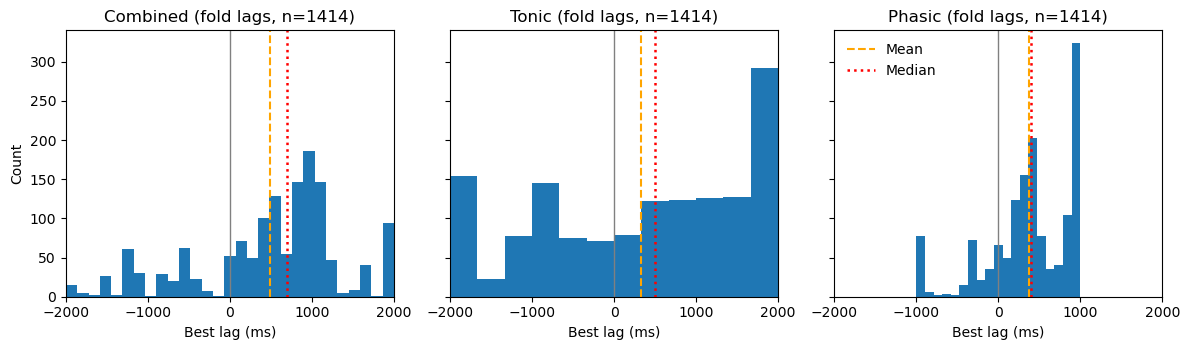

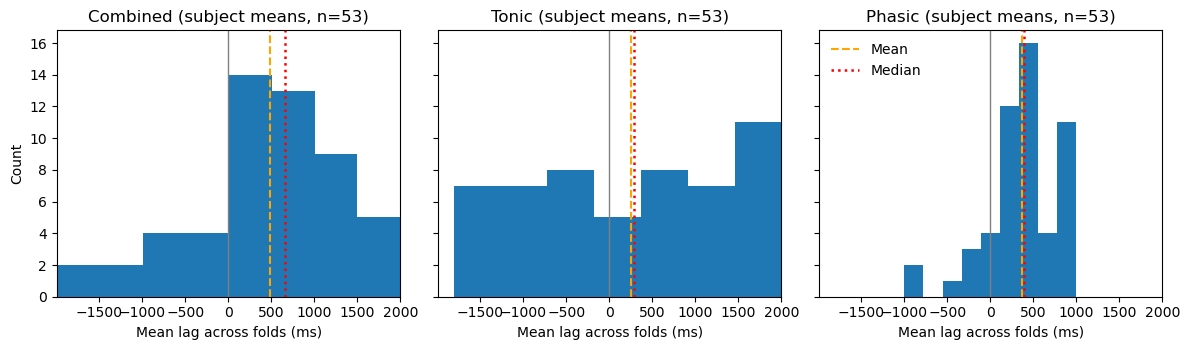

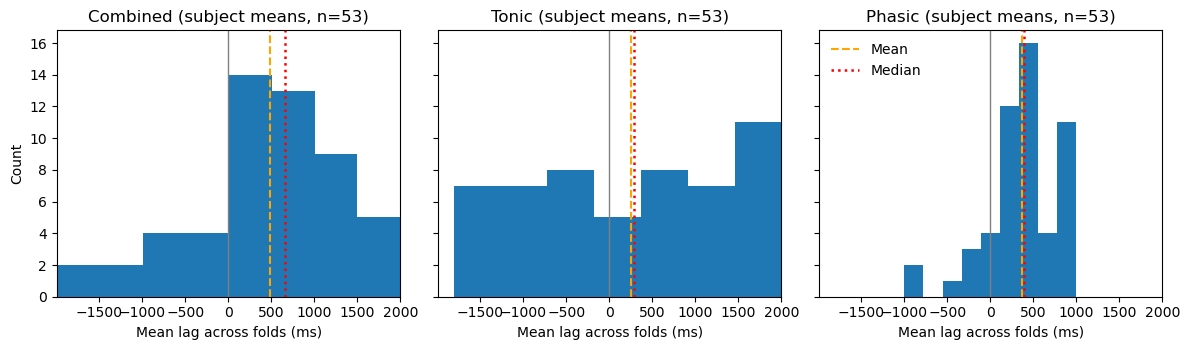

In [61]:
roots = {
    "Combined": r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit_ALL",
    "Tonic":    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit",
    "Phasic":   r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit_FAST",
}

# 1) all-fold lags (one lag per subject×fold), selecting the best lag per fold by mean corr
plot_fold_lag_histograms_1x3(roots, select="best", score="corr")

# 2) per-subject mean lag across folds (one value per subject)
plot_subject_mean_lag_histograms_1x3(roots, select="best", score="corr")


In [93]:
import re
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def _parse_subject_int(subject_str):
    # accepts "sub-33", "33", etc.
    m = re.search(r"(\d+)", str(subject_str))
    return int(m.group(1)) if m else np.nan

def fold_lags_from_npz_root(root_dir, *, invert_sign=True):
    df = collect_trial_npz_scores(root_dir)

    # subject as int
    df["subject"] = df["subject"].map(_parse_subject_int).astype(int)

    # sanity check: is lag unique per subject×fold?
    nun = df.groupby(["subject", "fold"])["lag_ms"].nunique()
    bad = nun[nun > 1]
    if len(bad):
        print("WARNING: some subject×fold have >1 lag_ms. Showing first few:")
        print(bad.head(10))

    # one row per subject×fold
    fold_lags = (
        df.sort_values(["subject", "fold", "path"])
          .groupby(["subject", "fold"], as_index=False)
          .agg(lag_ms=("lag_ms", "first"))
    )

    if invert_sign:
        fold_lags["lag_ms"] = -fold_lags["lag_ms"]

    return fold_lags
def subject_lag_stability(fold_lags: pd.DataFrame):
    # fold_lags columns: subject, fold, lag_ms
    def iqr(x):
        return float(np.nanquantile(x, 0.75) - np.nanquantile(x, 0.25))

    sub = (
        fold_lags.groupby("subject", as_index=False)
        .agg(
            cv_lag_mean=("lag_ms", "mean"),
            cv_lag_median=("lag_ms", "median"),
            cv_lag_sd=("lag_ms", "std"),      # SD across folds (ddof=1)
            cv_lag_iqr=("lag_ms", iqr),
            n_folds=("lag_ms", "size"),
        )
    )
    return sub

def summarize_stability(sub_stab: pd.DataFrame):
    # quick group-level summary of how “wobbly” lags are across folds
    sd = sub_stab["cv_lag_sd"].dropna()
    iqr = sub_stab["cv_lag_iqr"].dropna()
    print("Subjects:", len(sub_stab))
    print("Median SD across folds (ms):", float(np.nanmedian(sd)))
    print("IQR of SD across folds (ms):",
          float(np.nanquantile(sd, 0.75) - np.nanquantile(sd, 0.25)))
    print("Median IQR across folds (ms):", float(np.nanmedian(iqr)))


In [98]:
fold_lags_tonic = fold_lags_from_npz_root(
    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit",
    invert_sign=True
)
fold_lags_fast = fold_lags_from_npz_root(
    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit_FAST",
    invert_sign=True
)
fold_lags_all = fold_lags_from_npz_root(
    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\cv_trial_predictions_digit_ALL",
    invert_sign=True
)
sub_stab_tonic = subject_lag_stability(fold_lags_tonic)
sub_stab_fast = subject_lag_stability(fold_lags_fast)
sub_stab_all = subject_lag_stability(fold_lags_all)
summarize_stability(sub_stab_tonic)
sub_stab_tonic.head()


Subjects: 53
Median SD across folds (ms): 189.8728348254025
IQR of SD across folds (ms): 745.7492871506025
Median IQR across folds (ms): 200.0


,subject,cv_lag_mean,cv_lag_median,cv_lag_sd,cv_lag_iqr,n_folds
0,33,-1771.428571,-2000.0,942.016432,0.0,35
1,34,1400.000000,1400.0,98.373875,200.0,32
2,36,285.714286,700.0,946.944189,275.0,14
3,38,63.157895,700.0,1864.048916,4000.0,19
4,39,-956.000000,-1100.0,629.205849,200.0,25


In [99]:
def merge_with_refit_lag(sub_stab: pd.DataFrame, dfk_path, *, invert_sign=True):
    dfk = pd.read_csv(dfk_path)
    dfk["subject"] = dfk["subject"].astype(int)

    refit = dfk[["subject", "best_lag_ms_star"]].copy()
    refit = refit.rename(columns={"best_lag_ms_star": "refit_lag_ms"})
    if invert_sign:
        refit["refit_lag_ms"] = -refit["refit_lag_ms"]

    merged = sub_stab.merge(refit, on="subject", how="inner")
    merged["delta_refit_minus_cvmean"] = merged["refit_lag_ms"] - merged["cv_lag_mean"]
    merged["delta_refit_minus_cvmed"]  = merged["refit_lag_ms"] - merged["cv_lag_median"]
    return merged

def agreement_stats(merged: pd.DataFrame):
    x = merged["refit_lag_ms"].to_numpy(float)
    y = merged["cv_lag_mean"].to_numpy(float)

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]

    rp = pearsonr(x, y)[0] if len(x) > 1 else np.nan
    rs = spearmanr(x, y, nan_policy="omit")[0] if len(x) > 1 else np.nan

    d = merged["delta_refit_minus_cvmean"].to_numpy(float)
    d = d[np.isfinite(d)]
    print("N merged subjects:", len(x))
    print("Pearson(refit, CV mean):", float(rp))
    print("Spearman(refit, CV mean):", float(rs))
    print("Delta (refit - CV mean) median [IQR] (ms):",
          float(np.nanmedian(d)),
          float(np.nanquantile(d, 0.75) - np.nanquantile(d, 0.25)))

merged_tonic = merge_with_refit_lag(
    sub_stab_tonic,
    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_SLOW\dfk_ridge.csv",
    invert_sign=True
)
merged_all = merge_with_refit_lag(
    sub_stab_all,
    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\2seconds_window_ALL\dfk_ridge_ALL.csv",
    invert_sign=True
)
merged_fast = merge_with_refit_lag(
    sub_stab_fast,
    r"C:\Users\cdd\Documents\Uni\Special_course\code\Special_course\THESIS\ridge_reg\1seconds_window_FAST\dfk_ridge.csv",
    invert_sign=True
)
print("Tonic")
agreement_stats(merged_tonic)
print("Fast")
agreement_stats(merged_fast)
print("All")
agreement_stats(merged_all)



Tonic
N merged subjects: 53
Pearson(refit, CV mean): 0.9403794654694405
Spearman(refit, CV mean): 0.9448200645066065
Delta (refit - CV mean) median [IQR] (ms): 0.0 88.29493087557609
Fast
N merged subjects: 53
Pearson(refit, CV mean): 0.8595661152384404
Spearman(refit, CV mean): 0.7497507497998969
Delta (refit - CV mean) median [IQR] (ms): 0.0 43.38461538461536
All
N merged subjects: 53
Pearson(refit, CV mean): 0.9582232183335252
Spearman(refit, CV mean): 0.917094193268544
Delta (refit - CV mean) median [IQR] (ms): 0.0 47.05882352941177
